In [44]:
import pandas as pd 
import seaborn as sns 
import numpy as np 
import scipy.stats 
from scipy.stats import skew 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [45]:
import os

In [46]:

df = pd.read_csv("C:\\Users\\lenovo\\OneDrive\\Documents\\advertising.csv")

In [47]:
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [48]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [49]:
# EDA 

In [50]:
df.shape

(200, 4)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [52]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [53]:
df.duplicated().sum()

0

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [59]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


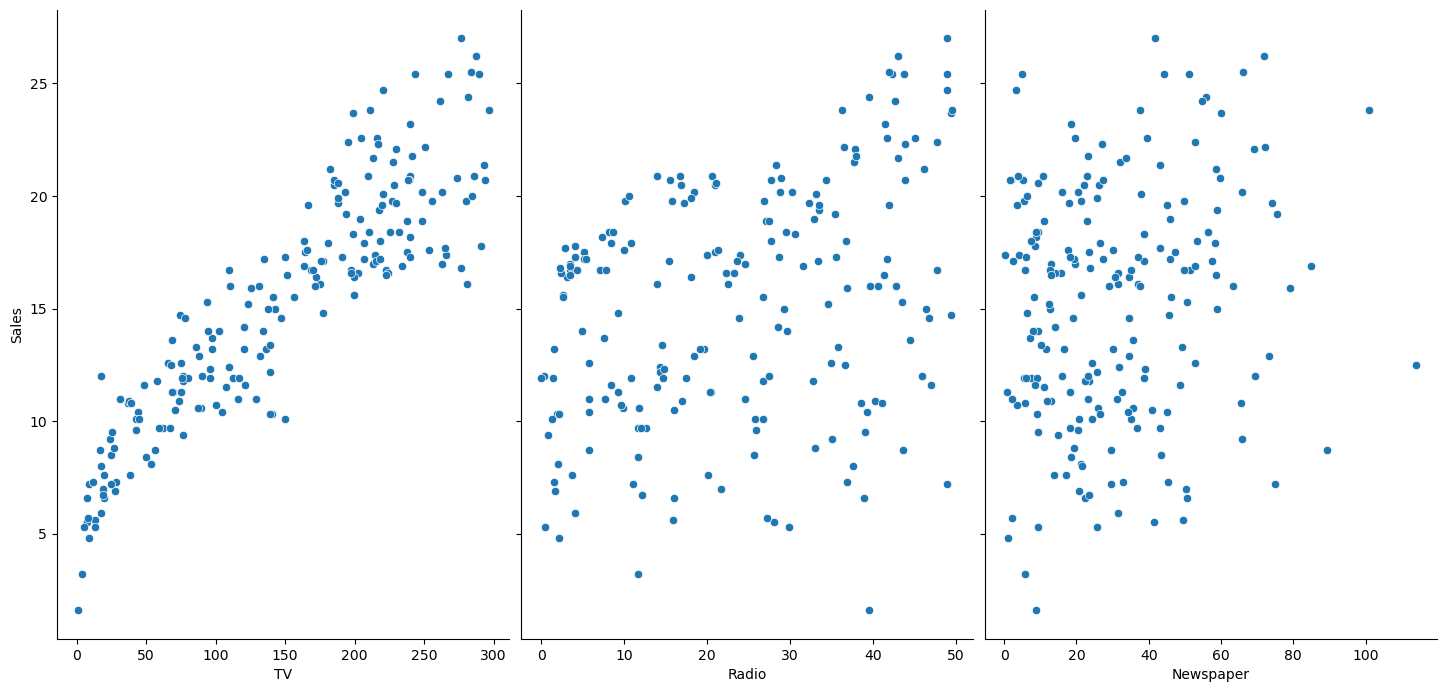

In [62]:
sns.pairplot(df,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=7,aspect=0.7)

### Individual Scatter Plots 
 Saler vs TV,
 Saler vs Radio,
 Saler vs Newspaper.

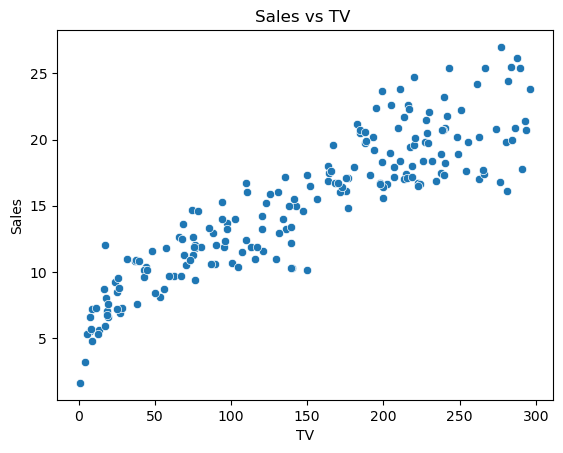

In [64]:
sns.scatterplot(x="TV",y="Sales",data=df)
plt.title("Sales vs TV ")
plt.show()

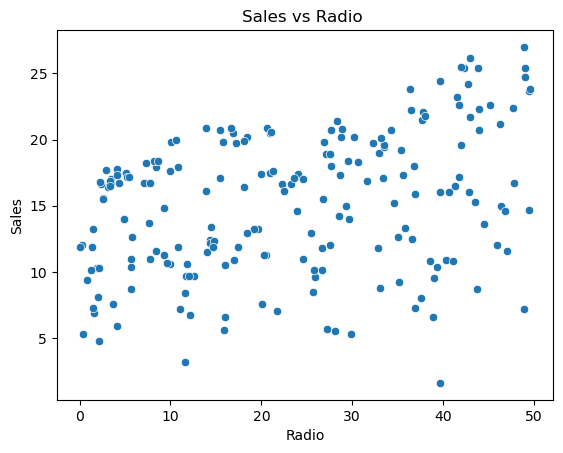

In [65]:
sns.scatterplot(x="Radio",y="Sales",data=df)
plt.title("Sales vs Radio ")
plt.show()

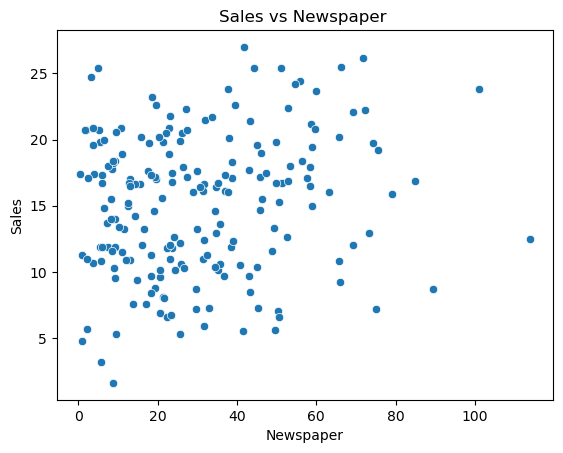

In [67]:
sns.scatterplot(x="Newspaper",y="Sales",data=df)
plt.title("Sales vs Newspaper ")
plt.show()

#### Interpretation
TV advertising shows the strongest positive relationship with Sales. Radio also has a positive relationship, while Newspaper shows a comparatively weak relationship.

### Correlation Matrix Heatmap

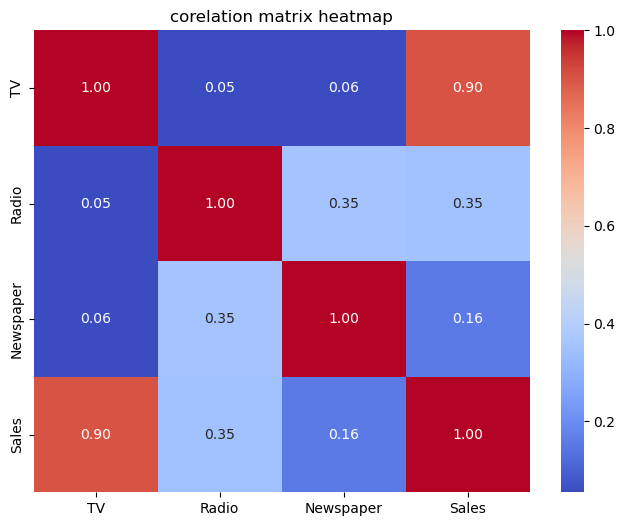

In [69]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("corelation matrix heatmap")
plt.show()


## Train/Test Split

In [70]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

## Linear Regression - Baseline Model

In [71]:
lr_model=LinearRegression()
lr_model.fit(X_train,y_train)
y_pred_lr=lr_model.predict(X_test)

In [72]:
mae_lr=mean_absolute_error(y_test,y_pred_lr)
rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred_lr))
r2_lr=r2_score(y_test,y_pred_lr)
print(mae_lr)
print(rmse_lr)
print(r2_lr)

1.274826210954934
1.7052146229349228
0.9059011844150826


## Additional Model — Random Forest Regressor

In [76]:

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)

In [77]:
mae_rf=mean_absolute_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))
r2_rf=r2_score(y_test,y_pred_rf)
print(mae_rf)
print(rmse_rf)
print(r2_rf)

0.9179999999999993
1.1989298770153327
0.9534827934927883


In [78]:
results=pd.DataFrame(
    {"Model":["Linear Regression","Random Forest"],
     "MAE":[mae_lr,mae_rf],
     "RMSE":[rmse_lr,rmse_rf],
     "R2 Score":[r2_lr,r2_rf]})
print(results)

               Model       MAE      RMSE  R2 Score
0  Linear Regression  1.274826  1.705215  0.905901
1      Random Forest  0.918000  1.198930  0.953483


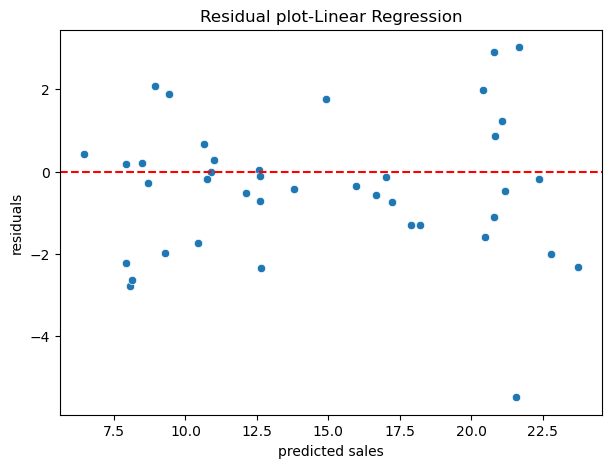

In [79]:

residuals=y_test-y_pred_lr

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_pred_lr,y=residuals)

plt.axhline(y=0,color="red",linestyle="--")
plt.xlabel("predicted sales")
plt.ylabel("residuals")
plt.title("Residual plot-Linear Regression")
plt.show()


In [81]:
coefficients=pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":lr_model.coef_
})
coefficients=coefficients.sort_values(
    by="Coefficient",
    ascending=False
)
coefficients

,Feature,Coefficient
1,Radio,0.100945
0,TV,0.054509
2,Newspaper,0.004337


In [83]:
new_data=pd.DataFrame({
    "TV":[150],
    "Radio":[25],
    "Newspaper":[30]
        })

prediction=lr_model.predict(new_data)
print("predicted sales:",prediction[0])

predicted sales: 15.54425049228201
